# parameter-flow, conceptually...

A conceptual walk-through the concepts behind parameter-flow.

1. [A family of distributions](#1)
2. [Two notions of "time": flow matching vs parameter-flow](#2)
3. [The continuity equation is mass conservation](#3)
4. [The velocity field and its characteristics](#4)
5. [Why a scalar potential: the curl-free gauge](#5)
6. [The elliptic PDE, term by term](#6)
7. [Score supply: running the PDE backwards](#7)
8. [Why $\dim\Theta = 1$ (for now): path dependence](#8)

Throughout we use the following toy family:

$$p_\theta(x) \;=\; \mathcal{N}(x;\,0,\,1)\,\bigl(1 + \theta\tanh x\bigr),
\qquad \theta \in (-1, 1),$$

which is just a Gaussian with a smooth, $\theta$-controlled left/right tilt.

$$\partial_\theta \log p_\theta = \frac{\tanh x}{1+\theta\tanh x},
\qquad
\nabla_x \log p_\theta = -x + \frac{\theta\,\mathrm{sech}^2 x}{1+\theta\tanh x}.$$


In [ ]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

from pm_utils import p0, p_theta, joint_score, spatial_score, v_true

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)
torch.set_default_dtype(torch.float64)
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-dark.mplstyle')

GRID = torch.linspace(-4.5, 4.5, 601)

<a id="1"></a>
## 1. A family of distributions

Each value of $\theta$ is one member of the family. We can "turn the knob" and probability mass slides simply and smoothly from one side to the other.  Parameter-flow is thus then used to decide what velocity field carries the samples along as this knob turns


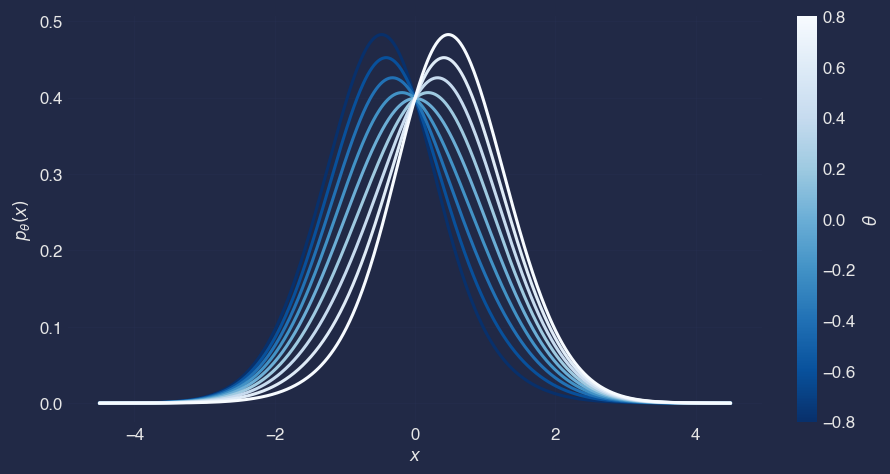

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.2), layout="constrained")
thetas = np.linspace(-0.8, 0.8, 9)
cmap = plt.cm.Blues_r
for th in thetas:
    ax.plot(
        GRID,
        p_theta(GRID, torch.tensor(th)),
        color=cmap((th + 0.8) / 1.6),
        lw=2,
    )
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(-0.8, 0.8))
fig.colorbar(sm, ax=ax, label=r"$\theta$")
ax.set_xlabel("$x$")
ax.set_ylabel(r"$p_\theta(x)$")
plt.show()


<a id="2"></a>
## 2. Two notions of time

Ordinary flow matching transports noise to data, where its clock $t$ parameterises a path in distribution space whose intermediate marginals are artificial blends; they belong to no physical family!!
they belong to no physical family.

On the other hand, parameter-flow transports $p_{\theta_0} \to p_{\theta_1}$, such that its clock $s$ parameterises a path $\theta(s)$ in parameter space, and every intermediate marginal is a genuine member of the family $p_{\theta(s)}$.  This is the very same continuity-equation machinery, but completely different semantics. We can in this case view `ParameterFlow` as a sibling of `FlowMatching`, and 
not a subclass.


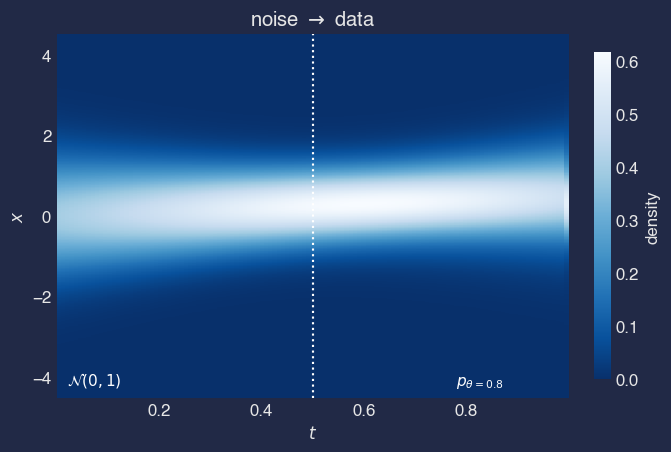

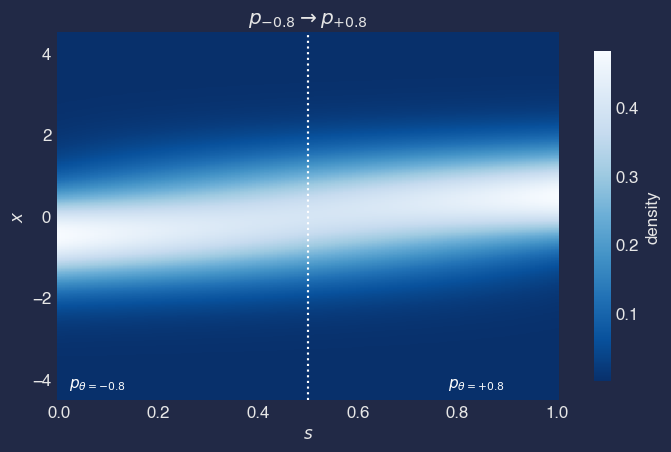

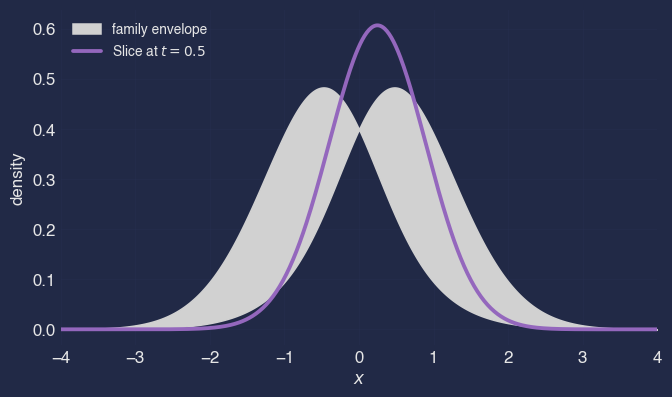

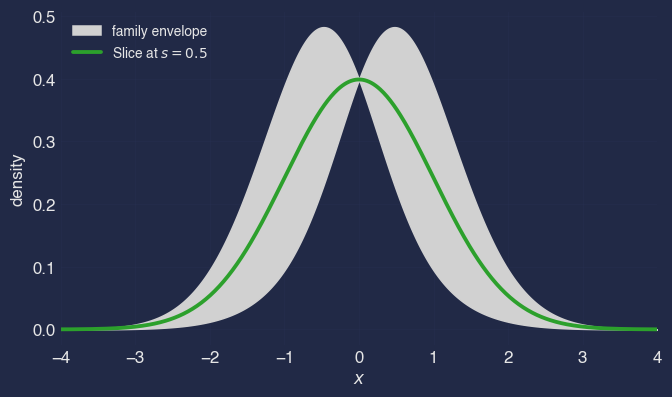

In [ ]:
# [Left] flow-matching marginals of x_t = (1-t) z + t x1, z ~ N(0,1), x1 ~ p_{0.8}.


# [Right] parameter-flow marginals p_{theta(s)} with theta(s) = (1-s)(-0.8) + s(0.8).


ts = torch.linspace(0.005, 0.995, 121)
u = GRID  # integration variable

fm = torch.empty(len(ts), len(GRID))
target = p_theta(u, torch.tensor(0.8))


for i, t in enumerate(ts):
    # p_t(y) = int N(y - t*u; 0, (1-t)^2) p_target(u) du
    kern = torch.exp(-0.5 * ((GRID[:, None] - t * u[None, :]) / (1 - t)) ** 2)
    kern = kern / ((1 - t) * math.sqrt(2 * math.pi))
    fm[i] = torch.trapezoid(kern * target[None, :], u, dim=-1)

ss = torch.linspace(0, 1, 121)
pf = torch.stack([p_theta(GRID, (1 - s) * (-0.8) + s * 0.8) for s in ss])

fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
im = ax.pcolormesh(ts, GRID, fm.T, cmap="Blues_r", shading="auto")
ax.set_xlabel("$t$")
ax.set_ylabel("$x$")
ax.set_title("noise $\\to$ data")
ax.axvline(0.5, color="w", ls=":", lw=1.4)
ax.text(0.02, -4.2, "$\\mathcal{N}(0,1)$", color="w", fontsize=10)
ax.text(0.78, -4.2, "$p_{\\theta=0.8}$", color="w", fontsize=10)
fig.colorbar(im, ax=ax, label="density", shrink=0.9)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
im = ax.pcolormesh(ss, GRID, pf.T, cmap="Blues_r", shading="auto")
ax.set_xlabel("$s$")
ax.set_ylabel("$x$")
ax.set_title("$p_{-0.8} \\to p_{+0.8}$")
ax.axvline(0.5, color="w", ls=":", lw=1.4)
ax.text(0.02, -4.2, "$p_{\\theta=-0.8}$", color="w", fontsize=10)
ax.text(0.78, -4.2, "$p_{\\theta=+0.8}$", color="w", fontsize=10)
fig.colorbar(im, ax=ax, label="density", shrink=0.9)
plt.show()

# the midpoint slices against the grey envelope swept by all family members theta in [-0.8, 0.8].
fam = torch.stack(
    [p_theta(GRID, torch.tensor(th)) for th in np.linspace(-0.8, 0.8, 81)]
)

fig, ax = plt.subplots(figsize=(6, 3.5), layout="constrained")
ax.fill_between(GRID, fam.amin(0), fam.amax(0), color="0.82", label="family envelope")
fm_mid = fm[torch.argmin((ts - 0.5).abs())]
ax.plot(GRID, fm_mid, color="tab:purple", lw=2.5, label="Slice at $t=0.5$")
ax.set_xlim(-4, 4)
ax.set_xlabel("$x$")
ax.set_ylabel("density")
ax.legend(fontsize=9, loc="upper left")
plt.show()

fig, ax = plt.subplots(figsize=(6, 3.5), layout="constrained")
ax.fill_between(GRID, fam.amin(0), fam.amax(0), color="0.82", label="family envelope")
pf_mid = pf[torch.argmin((ss - 0.5).abs())]
ax.plot(GRID, pf_mid, color="tab:green", lw=2.5, label="Slice at $s=0.5$")
ax.set_xlim(-4, 4)
ax.set_xlabel("$x$")
ax.set_ylabel("density")
ax.legend(fontsize=9, loc="upper left")
plt.show()


<a id="3"></a>
## 3. The continuity equation is mass conservation

If the density changes with $\theta$, mass must flow. The flux $p_\theta v$ and the density change are locked together by

$$\partial_\theta p_\theta(x) + \partial_x\bigl(p_\theta(x)\, v(x;\theta)\bigr) = 0 .$$

Where mass appears ($\partial_\theta p > 0$, right half), so flux must converge; where mass disappears (left half), flux diverges.

The flux itself is a single right-moving bump, and the tilt slides mass from left toright. $v$ is exactly the velocity of that slide.


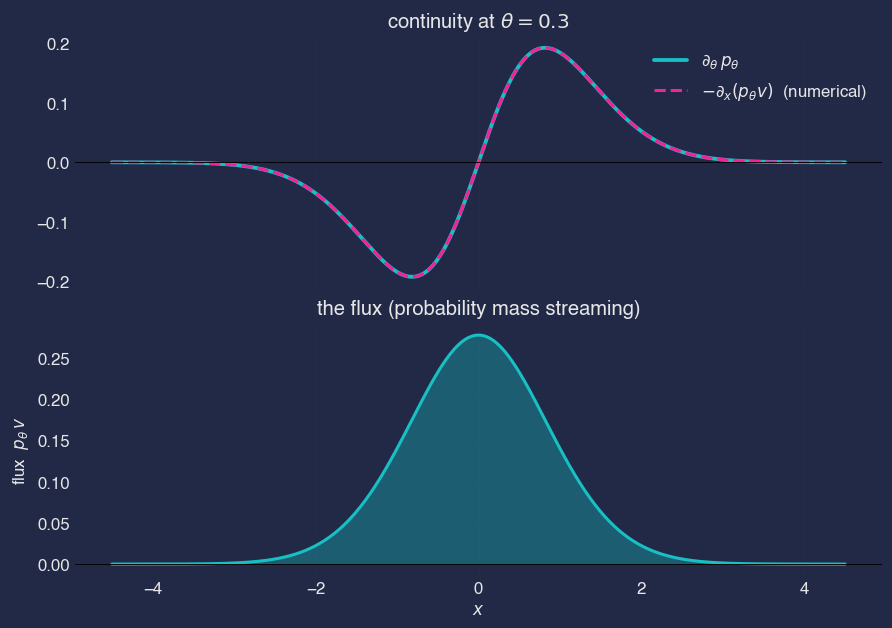

In [12]:
th = 0.3
dp = p0(GRID) * torch.tanh(GRID)
flux = p_theta(GRID, torch.tensor(th)) * v_true(GRID, th)
minus_dflux = -torch.gradient(flux, spacing=(GRID,))[0]

fig, axes = plt.subplots(2, 1, figsize=(8, 5.6), sharex=True, layout="constrained")
axes[0].plot(GRID, dp, lw=2.5, label=r"$\partial_\theta\, p_\theta$")
axes[0].plot(
    GRID, minus_dflux, "--", lw=2, label=r"$-\partial_x (p_\theta v)$  (numerical)"
)
axes[0].axhline(0, color="k", lw=0.6)
axes[0].legend()
axes[0].set_title(f"continuity at $\\theta = {th}$")

axes[1].fill_between(GRID, flux, alpha=0.35)
axes[1].plot(GRID, flux, lw=2)
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set_ylabel(r"flux  $p_\theta\, v$")
axes[1].set_xlabel("$x$")
axes[1].set_title("the flux (probability mass streaming)")
plt.show()


<a id="4"></a>
## 4. The velocity field and its characteristics

Solving $\dot x = \dot\theta(s)\, v(x; \theta(s))$ from many starting points draws the characteristics, the paths individual samples follow. In one dimension the curl-free transport is the monotone (quantile-preserving) map, so the characteristics are precisely the quantile curves of $p_{\theta(s)}$: the median follows the median, the 90th percentile follows the 90th percentile.


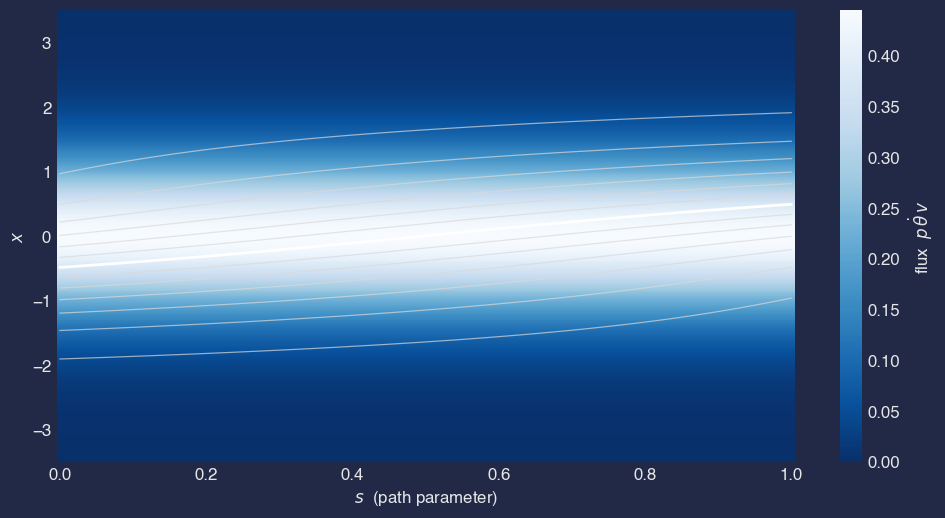

In [13]:
theta0, theta1 = -0.8, 0.8
quantiles = np.linspace(0.05, 0.95, 13)

# quantile curves of p_theta(s)
qcurves = np.empty((len(ss), len(quantiles)))
for i, s in enumerate(ss):
    th_s = (1 - s.item()) * theta0 + s.item() * theta1
    pdf = p_theta(GRID, torch.tensor(th_s))
    cdf = torch.cat([torch.zeros(1), torch.cumulative_trapezoid(pdf, GRID)])
    cdf = cdf / cdf[-1]
    qcurves[i] = np.interp(quantiles, cdf.numpy(), GRID.numpy())

FLUX = torch.stack(
    [
        p_theta(GRID, torch.tensor((1 - s) * theta0 + s * theta1))
        * (theta1 - theta0)
        * v_true(GRID, (1 - s) * theta0 + s * theta1)
        for s in ss.tolist()
    ]
)

fig, ax = plt.subplots(figsize=(8.5, 4.6), layout="constrained")
im = ax.pcolormesh(ss, GRID, FLUX.T, cmap="Blues_r", shading="auto")
for j, q in enumerate(quantiles):
    is_median = abs(q - 0.5) < 1e-9
    ax.plot(ss, qcurves[:, j], color="w" if is_median else "0.85",
            lw=1.8 if is_median else 0.8, alpha=1.0 if is_median else 0.7)
ax.set_ylim(-3.5, 3.5)
ax.set_xlabel("$s$  (path parameter)")
ax.set_ylabel("$x$")
fig.colorbar(im, ax=ax, label=r"flux  $p\,\dot\theta\, v$")
plt.show()


The glowing band is the river of probability; each quantile curve simply surfs the velocity field $\dot x = \dot\theta\, v$, drifting right as the tilt grows. This is what `ParameterFlowProcess.transport` integrates with an ODE
solver.


<a id="5"></a>
## 5. Why a scalar potential and the curl-free gauge trick

The continuity equation does not pin down $v$ uniquely: you can add any component that circulates without moving the density.  Below, a 2-d standard Gaussian is being inflated ($p_s = \mathcal{N}(0, \sigma^2(s) I)$).  Both fields transport it identically, but the right one wastes kinetic energy stirring particles around level sets.

Writing $v = \nabla_x \phi$ removes the swirl by construction (a gradient field has zero curl). The curl-free representative is the minimum-kinetic-energy transport, or in other words the Wasserstein geodesic.  This isthe `ScalarPotentialField`, and it is why a direct-velocity network with a soft curl penalty would lose the geometry, not just efficiency.


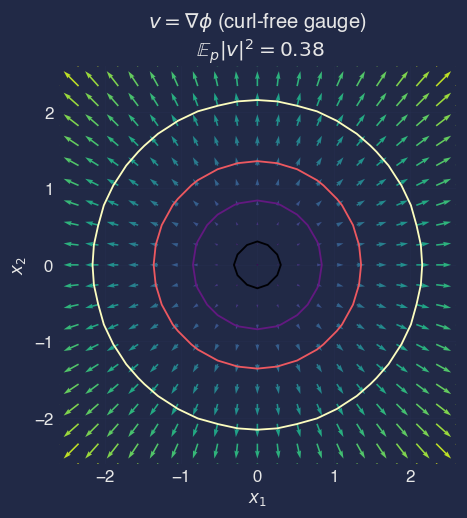

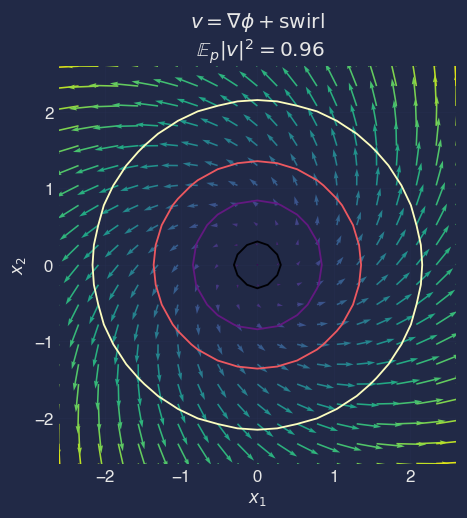

In [14]:
xx, yy = torch.meshgrid(
    torch.linspace(-2.6, 2.6, 21), torch.linspace(-2.6, 2.6, 21), indexing="xy"
)
r2 = xx**2 + yy**2

# inflating Gaussian: v = grad phi with phi = (a/2)|x|^2  ->  v = a x  (radial)
a = 0.45
vx_g, vy_g = a * xx, a * yy
# add a divergence-free swirl w = b(-y, x)
b = 0.55
vx_s, vy_s = vx_g - b * yy, vy_g + b * xx

dens = torch.exp(-0.5 * r2)
ke_g = float((dens * (vx_g**2 + vy_g**2)).sum() / dens.sum())
ke_s = float((dens * (vx_s**2 + vy_s**2)).sum() / dens.sum())

levels = [0.1, 0.4, 0.7, 0.95]

fig, ax = plt.subplots(figsize=(5, 4.6), layout="constrained")
ax.contour(xx, yy, dens, levels=levels, cmap="magma_r", linewidths=1.2)
speed_g = torch.sqrt(vx_g**2 + vy_g**2)
ax.quiver(xx, yy, vx_g, vy_g, speed_g, cmap="viridis", scale=28, width=0.004)
ax.set_title(
    r"$v = \nabla\phi$ (curl-free gauge)"
    f"\n $\\mathbb{{E}}_p|v|^2 = {ke_g:.2f}$"
)
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
plt.show()

fig, ax = plt.subplots(figsize=(5, 4.6), layout="constrained")
ax.contour(xx, yy, dens, levels=levels, cmap="magma_r", linewidths=1.2)
speed_s = torch.sqrt(vx_s**2 + vy_s**2)
ax.quiver(xx, yy, vx_s, vy_s, speed_s, cmap="viridis", scale=28, width=0.004)
ax.set_title(
    r"$v = \nabla\phi + \mathrm{swirl}$"
    f"\n $\\mathbb{{E}}_p|v|^2 = {ke_s:.2f}$"
)
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
plt.show()


<a id="6"></a>
## 6. The elliptic PDE, term by term

Divide the continuity equation by $p_\theta$ and substitute $v = \nabla_x\phi$:

$$\underbrace{\partial_\theta \log p_\theta}_{\text{joint score (input)}}
\;+\;
\underbrace{\Delta_x \phi}_{\text{network, 2nd order}}
\;+\;
\underbrace{\nabla_x\phi \cdot \nabla_x \log p_\theta}_{\text{network} \times \text{spatial score (input)}}
\;=\; 0 .$$

The two scores are frozen inputs supplied by estimators (`OracleScore` here, mining-gold or trained networks in general); only $\phi$ is trained, by squaring this residual. At the exact solution the three curves cancel pointwise.


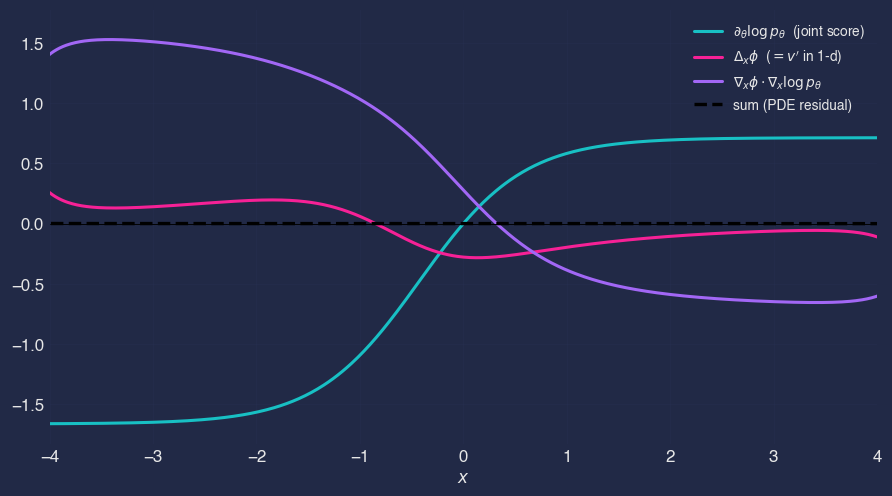

In [16]:
th = 0.4
v = v_true(GRID, th)
lap_phi = torch.gradient(v, spacing=(GRID,))[0]
term_A = joint_score(GRID, torch.tensor(th))
term_C = v * spatial_score(GRID, torch.tensor(th))
residual = term_A + lap_phi + term_C

fig, ax = plt.subplots(figsize=(8, 4.4), layout="constrained")

ax.plot(GRID, term_A, lw=2, label=r"$\partial_\theta \log p_\theta$  (joint score)")

ax.plot(GRID, lap_phi, lw=2, label=r"$\Delta_x\phi$  ($= v'$ in 1-d)")

ax.plot(GRID, term_C, lw=2,
        label=r"$\nabla_x\phi \cdot \nabla_x\log p_\theta$")

ax.plot(GRID, residual, "k--", lw=2.2, label="sum (PDE residual)")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlim(-4, 4)
ax.set_xlabel("$x$")
ax.legend(loc="upper right", fontsize=9)
plt.show()


Training `parameter_flow_loss` is nothing more than making the dashed black curve flat at zero, in expectation over $(x, \theta)$ samples.  The tiny non-zero residual here is finite-difference error in our numerical $v'$, not physics.


<a id="7"></a>
## 7. Score supply and running the PDE backwards

Rearranging the same PDE turns a trained $\phi$ into a joint-score estimator:

$$\partial_\theta \log \hat p_\theta(x)
 \;=\; -\Delta_x\phi \;-\; \nabla_x\phi \cdot \nabla_x\log p_\theta(x).$$

Note that you cannot autograd through $\phi$ alone since the recovery needs the spatial score at evaluation time.  That is why `ParameterFlowProcess.score_supply(x, theta, spatial_score=...)` has a required estimator argument.


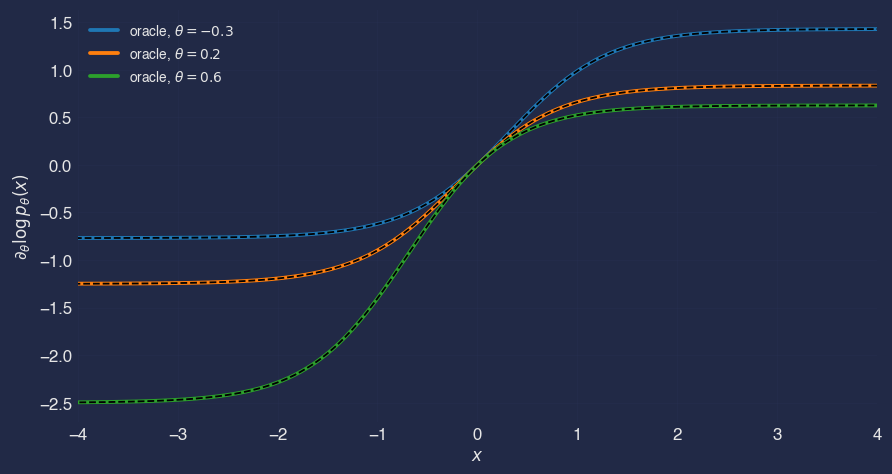

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.2), layout="constrained")
for th, color in ((-0.3, "tab:blue"), (0.2, "tab:orange"), (0.6, "tab:green")):
    v = v_true(GRID, th)
    lap = torch.gradient(v, spacing=(GRID,))[0]
    recovered = -lap - v * spatial_score(GRID, torch.tensor(th))
    ax.plot(GRID, joint_score(GRID, torch.tensor(th)), color=color, lw=2.5,
            label=f"oracle, $\\theta={th}$")
    ax.plot(GRID, recovered, "--", color="k", lw=1.2)
ax.set_xlim(-4, 4)
ax.set_xlabel("$x$")
ax.set_ylabel(r"$\partial_\theta \log p_\theta(x)$")
ax.legend(fontsize=9)
plt.show()


<a id="8"></a>
## 8. Why $\dim\Theta = 1$ (for now): path dependence

With a scalar knob there is only one way from $\theta_0$ to $\theta_1$ where every smooth path is a reparameterisation of the same segment, so the transport map is unambiguous.  

With $\theta \in \mathbb{R}^2$ the velocity along a direction $\dot\theta$ must be linear in $\dot\theta$, which forces one component potential per direction, $\psi = \sum_i \dot\theta_i\, \phi^i(x,\theta)$  and the cross-consistency conditions $\partial_{\theta_i}\nabla\phi^j = \partial_{\theta_j}\nabla\phi^i$ (Frobenius compatibility) are not automatic. Different routes to the same endpoint may give different maps


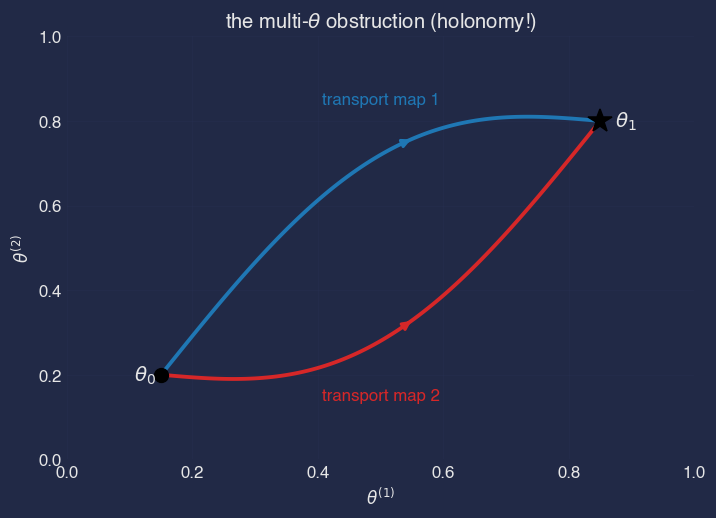

In [19]:
fig, ax = plt.subplots(figsize=(6.4, 4.6), layout="constrained")
A, B = np.array([0.15, 0.2]), np.array([0.85, 0.8])

t = np.linspace(0, 1, 100)
path1 = np.stack([A[0] + (B[0] - A[0]) * t, A[1] + (B[1] - A[1]) * t
                  + 0.22 * np.sin(np.pi * t)], axis=1)
path2 = np.stack([A[0] + (B[0] - A[0]) * t, A[1] + (B[1] - A[1]) * t
                  - 0.22 * np.sin(np.pi * t)], axis=1)
ax.plot(*path1.T, lw=2.5, color="tab:blue")
ax.plot(*path2.T, lw=2.5, color="tab:red")
for path, color in ((path1, "tab:blue"), (path2, "tab:red")):
    k = 55
    ax.annotate("", xy=path[k + 2], xytext=path[k],
                arrowprops={"arrowstyle": "-|>", "color": color, "lw": 2})
ax.plot(*A, "ko", ms=9)
ax.plot(*B, "k*", ms=16)

ax.annotate(r"$\theta_0$", A, textcoords="offset points", xytext=(-18, -4),
            fontsize=13)
ax.annotate(r"$\theta_1$", B, textcoords="offset points", xytext=(10, -4),
            fontsize=13)
ax.text(0.5, 0.84, "transport map 1", color="tab:blue", ha="center", fontsize=11)

ax.text(0.5, 0.14, "transport map 2", color="tab:red", ha="center", fontsize=11)

ax.set_xlabel(r"$\theta^{(1)}$")
ax.set_ylabel(r"$\theta^{(2)}$")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title(r"the multi-$\theta$ obstruction (holonomy!)")
plt.show()


At $\dim\Theta = 1$ this obstruction cannot exist (there is no loop to go around), which is exactly why Milestone 1 lives there: it tests the construction with zero geometric confounders.  `nami` enforces this honestly through `parameter_flow_loss` and `ParameterFlowProcess` which raise on multi-dimensional $\theta$ rather than silently broadcasting a single potential that cannot represent the transport.